<a href="https://colab.research.google.com/github/va4756/bigdata_raejung/blob/main/MachineLearning_%EA%B5%90%EA%B3%BC%EC%84%9C_%EB%B0%95%ED%95%B4%EC%84%A0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## chap 02

### 02-1.객체 지향 퍼셉트론 API

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [43]:
import numpy as np

In [44]:
class Perceptron(object):
    # 퍼셉트론 분류기
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        # 훈련 데이터 학습
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.errors_ = []

        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_[1:] += update * xi
                self.w_[0] += update
                errors += int(update !=0.0)
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        # 입력 계산
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        # 단위 계단 함수를 사용하여 클래스 레이블을 반환
        return np.where(self.net_input(X) >= 0.0, 1, -1)

In [45]:
v1 = np.array([1,2,3])
v2 = 0.5 * v1
np.arccos(v1.dot(v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

np.float64(0.0)

### 02-2.붓꽃 데이터셋에서 퍼셉트론 훈련

#### 2-1 붓꽃 데이터셋 읽기

In [46]:
import os
import pandas as pd

s = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
print('URL:', s)

df = pd.read_csv(s, header=None, encoding='utf-8')
print(df.shape)
df.head()

URL: https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data
(150, 5)


,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


#### 2-2 붓꽃 데이터 그래프 그리기

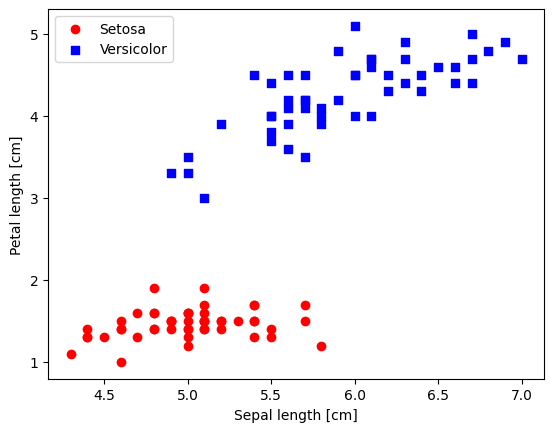

In [47]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# setosa와 versicolor를 선택
y = df.iloc[0:100, 4].values
y = np.where(y == 'Iris-setosa', 0, 1)

# 꽃받침 길이와 꽃잎 길이를 추출
X = df.iloc[0:100, [0, 2]].values

# 산점도를 그리기
plt.scatter(X[:50, 0], X[:50, 1],
            color='red', marker='o', label='Setosa')
plt.scatter(X[50:100, 0], X[50:100, 1],
            color='blue', marker='s', label='Versicolor')

plt.xlabel('Sepal length [cm]')
plt.ylabel('Petal length [cm]')
plt.legend(loc='upper left')

# plt.savefig('images/02_06.png', dpi=300)
plt.show()

#### 2-3 퍼셉트론 모델 훈련하기

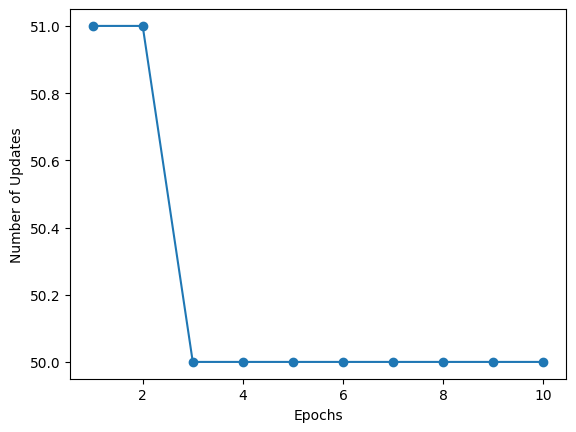

In [48]:
from matplotlib import markers
ppn = Perceptron(eta=0.1, n_iter=10)

ppn.fit(X, y)

plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Number of Updates')

# plt.savefig('images/02_07.png', dpi=300)
plt.show()

#### 2-4 결정 경계 그래프 함수

In [49]:
from matplotlib.colors import ListedColormap

In [50]:
def plot_decision_regions(X, y, classifier, resolution=0.02):

    # 마커와 컬러맵을 설정
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # 샘플의 산점도 그리기
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    edgecolor='black')

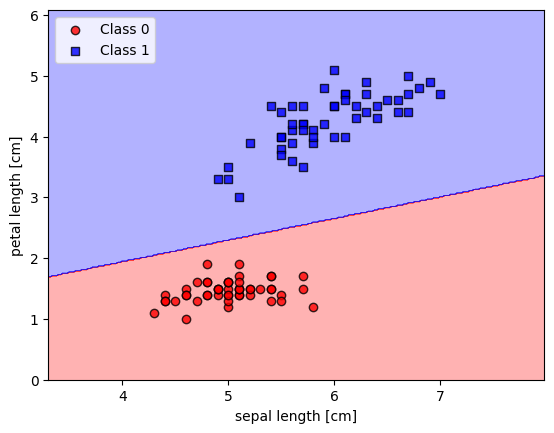

In [51]:
plot_decision_regions(X, y, classifier=ppn)
plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')

# plt.savefig('images/02_08.png', dpi=300)
plt.show()

### 02-3.적응형 선형 뉴런과 학습의 수렴

#### 3-1 경사 하강법으로 비용 함수 최소화

#### 3-2 파이썬으로 아달린 구현하기

In [52]:
class AdalineGD:
    # 적응형 선형 뉴런 분류기

    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        # 훈련 데이터 학습
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.)
        self.losses_ = []

        for i in range(self.n_iter):
            net_input = self.net_input(X)

            output = self.activation(net_input)
            errors = (y - output)

            #for w_j in range(self.w_.shape[0]):
            #    self.w_[w_j] += self.eta * (2.0 * (X[:, w_j]*errors)).mean()

            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()
            loss = (errors**2).mean()
            self.losses_.append(loss)
        return self

    def net_input(self, X):
        """최종 입력 계산"""
        return np.dot(X, self.w_) + self.b_

    def activation(self, X):
        """선형 활성화 계산"""
        return X

    def predict(self, X):
        """단위 계단 함수를 사용하여 클래스 레이블 반환"""
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

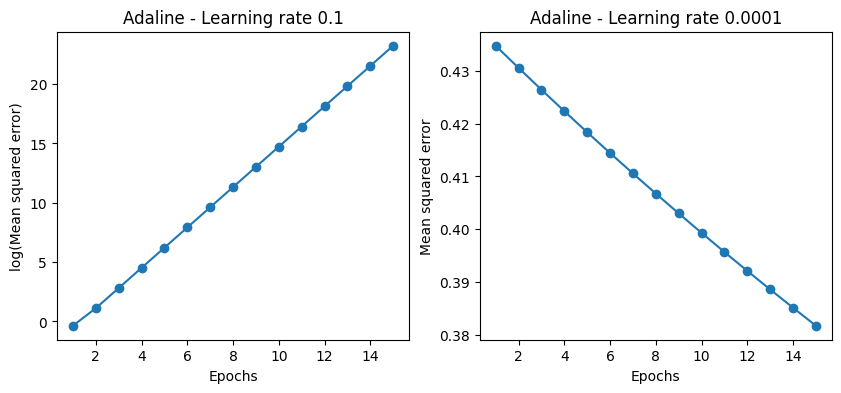

In [53]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

ada1 = AdalineGD(n_iter=15, eta=0.1).fit(X, y)
ax[0].plot(range(1, len(ada1.losses_) + 1), np.log10(ada1.losses_), marker='o')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('log(Mean squared error)')
ax[0].set_title('Adaline - Learning rate 0.1')

ada2 = AdalineGD(n_iter=15, eta=0.0001).fit(X, y)
ax[1].plot(range(1, len(ada2.losses_) + 1), ada2.losses_, marker='o')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Mean squared error')
ax[1].set_title('Adaline - Learning rate 0.0001')

# plt.savefig('images/02_11.png', dpi=300)
plt.show()

#### 3-3 특성 스케일을 조정하여 경사 하강법 결과 향상

In [54]:
# 특성을 표준화
X_std = np.copy(X)
X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

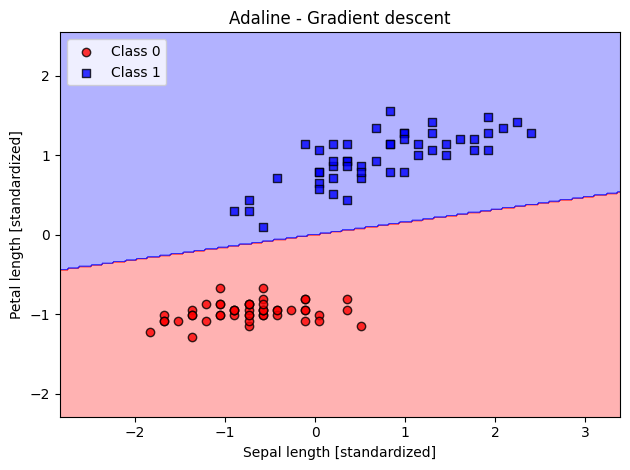

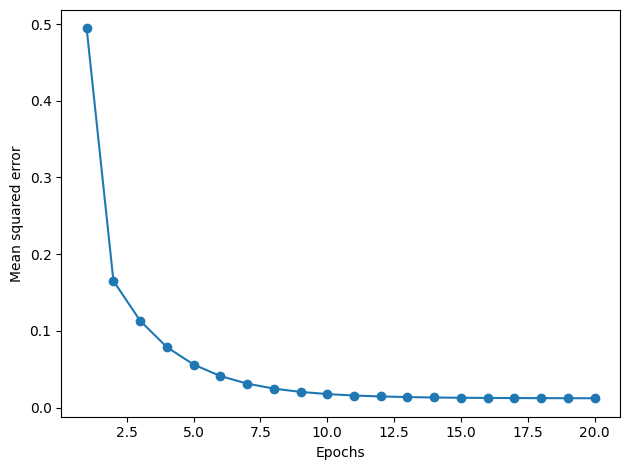

In [55]:
ada_gd = AdalineGD(n_iter=20, eta=0.5)
ada_gd.fit(X_std, y)

plot_decision_regions(X_std, y, classifier=ada_gd)
plt.title('Adaline - Gradient descent')
plt.xlabel('Sepal length [standardized]')
plt.ylabel('Petal length [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
#plt.savefig('images/02_14_1.png', dpi=300)
plt.show()

plt.plot(range(1, len(ada_gd.losses_) + 1), ada_gd.losses_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Mean squared error')

plt.tight_layout()
#plt.savefig('images/02_14_2.png', dpi=300)
plt.show()

#### 3-4 대규모 머신 러닝과 확률적 경사 하강법

In [56]:
class AdalineSGD:
    # ADAptive LInear NEuron 분류기
    def __init__(self, eta=0.01, n_iter=10, shuffle=True, random_state=None):
        self.eta = eta
        self.n_iter = n_iter
        self.w_initialized = False
        self.shuffle = shuffle
        self.random_state = random_state

    def fit(self, X, y):
        self._initialize_weights(X.shape[1])
        self.losses_ = []
        for i in range(self.n_iter):
            if self.shuffle:
                X, y = self._shuffle(X, y)
            losses = []
            for xi, target in zip(X, y):
                losses.append(self._update_weights(xi, target))
            avg_loss = np.mean(losses)
            self.losses_.append(avg_loss)
        return self

    def partial_fit(self, X, y):
        # 가중치를 다시 초기화하지 않고 훈련 데이터를 학습
        if not self.w_initialized:
            self._initialize_weights(X.shape[1])
        if y.ravel().shape[0] > 1:
            for xi, target in zip(X, y):
                self._update_weights(xi, target)
        else:
            self._update_weights(X, y)
        return self

    def _shuffle(self, X, y):
        # 훈련 데이터를 섞음
        r = self.regen.permutation(len(y))
        return X[r], y[r]

    def _initialize_weights(self, m):
        # 랜덤한 작은 수로 가중치를 초기화
        self.regen = np.random.RandomState(self.random_state)
        self.w_ = self.regen.normal(loc=0.0, scale=0.01, size=m)
        self.b_ = np.float64(0.)
        self.w_initialized = True

    def _update_weights(self, xi, target):
        # 아달린 학습 규칙을 적용하여 가중치를 업데이트
        output = self.activation(self.net_input(xi))
        error = (target - output)
        self.w_ += self.eta * 2.0 * xi * error
        self.b_ += self.eta * 2.0 * error
        loss = error**2
        return loss

    def net_input(self, X):
        # 입력 계산
        return np.dot(X, self.w_) + self.b_

    def activation(self, X):
        # 선형 활성화 계산
        return X

    def predict(self, X):
        # 단위 계단 함수를 사용하여 클래스 레이블을 반환
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

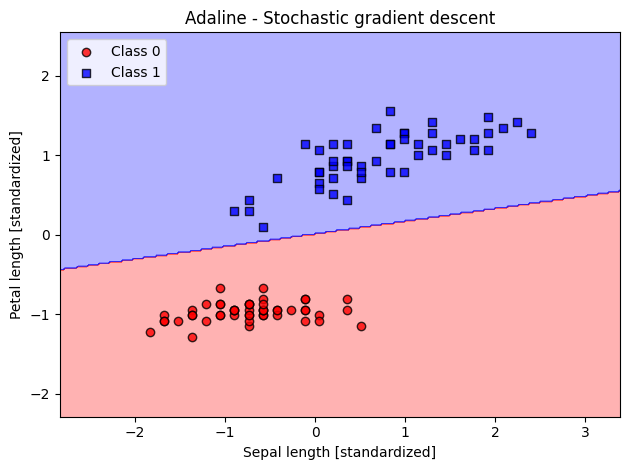

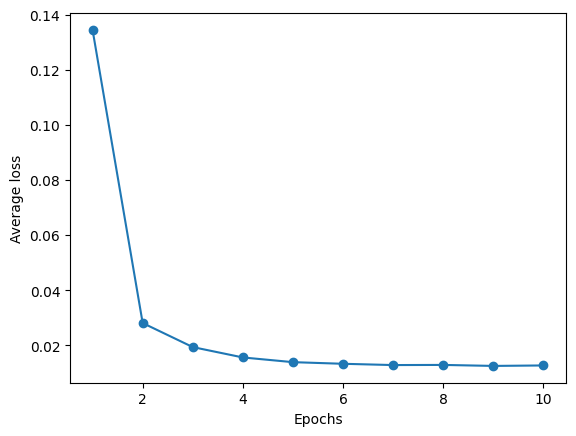

In [57]:
ada_sgd = AdalineSGD(n_iter=10, eta=0.01, random_state=1)
ada_sgd.fit(X_std, y)

plot_decision_regions(X_std, y, classifier=ada_sgd)
plt.title('Adaline - Stochastic gradient descent')
plt.xlabel('Sepal length [standardized]')
plt.ylabel('Petal length [standardized]')
plt.legend(loc='upper left')

plt.tight_layout()
#plt.savefig('figures/02_15_1.png', dpi=300)
plt.show()

plt.plot(range(1, len(ada_sgd.losses_) + 1), ada_sgd.losses_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Average loss')

#plt.savefig('figures/02_15_2.png', dpi=300)
plt.show()

In [58]:
ada_sgd.partial_fit(X_std[0, :], y[0])

## 03장 - 사이킷런을 타고 떠나는 머신 러닝 분류 모델 투어

In [59]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
from IPython.display import Image
%matplotlib inline

### 03-1 분류 알고리즘 선택

#### 1-1 사이킷런 첫걸음: 퍼셉트론 훈련

In [61]:
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [62]:
iris.feature_names, iris.target_names

(['sepal length (cm)',
  'sepal width (cm)',
  'petal length (cm)',
  'petal width (cm)'],
 array(['setosa', 'versicolor', 'virginica'], dtype='<U10'))

In [63]:
X = iris.data[:, [2, 3]]
y = iris.target

print('클래스 레이블:', np.unique(y))

클래스 레이블: [0 1 2]


In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3,
    random_state=1,
    stratify=y)

In [65]:
print('y의 레이블 카운트:', np.bincount(y))
print('y_train의 레이블 카운트:', np.bincount(y_train))
print('y_test의 레이블 카운트:', np.bincount(y_test))

y의 레이블 카운트: [50 50 50]
y_train의 레이블 카운트: [35 35 35]
y_test의 레이블 카운트: [15 15 15]


In [66]:
# 특성을 표준화
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

#### 1-2 사이킷런 첫걸음: 퍼셉트론 훈련

In [67]:
from sklearn.linear_model import Perceptron

ppn = Perceptron(eta0=0.1, random_state=1)
ppn.fit(X_train_std, y_train)

Perceptron(eta0=0.1, random_state=1)

In [68]:
y_pred = ppn.predict(X_test_std)
print('잘못 분류된 샘플 개수: %d' % (y_test != y_pred).sum())

잘못 분류된 샘플 개수: 1


In [69]:
from sklearn.metrics import accuracy_score

print('정확도: %.3f' % accuracy_score(y_test, y_pred))

정확도: 0.978


In [70]:
print('정확도: %.3f' % ppn.score(X_test_std, y_test))

정확도: 0.978


In [71]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

# 맷플롯립 호환성을 체크
import matplotlib
from distutils.version import LooseVersion

In [72]:
def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # 마커와 컬러맵을 설정
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # 결정 경계를 그리기
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # 클래스 샘플을 그리기
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha = 0.8,
                    c = colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    edgecolor='black')

    # 테스트 샘플을 부각하여 그리기
    if test_idx:
        # 모든 샘플을 그리기
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0],
                    X_test[:, 1],
                    c='none',
                    edgecolor='black',
                    alpha=1.0,
                    linewidth=1,
                    marker='o',
                    s=100,
                    label='Test Set')

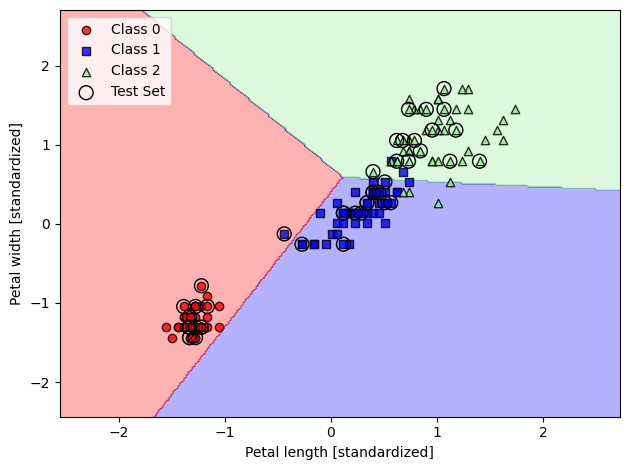

In [73]:
# 표준화한 훈련 데이터를 사용해 퍼셉트론 모델을 훈련
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))

plot_decision_regions(X=X_combined_std, y=y_combined,
                      classifier=ppn, test_idx=range(105, 150))
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')

plt.tight_layout()
#plt.savefig('figures/03_01.png', dpi=300)
plt.show()

### 03-2 로지스틱 회귀를 사용한 클래스 확률 모델링

#### 1-1 로지스틱 회귀의 이해와 조건부 확률

In [74]:
import matplotlib.pyplot as plt
import numpy as np

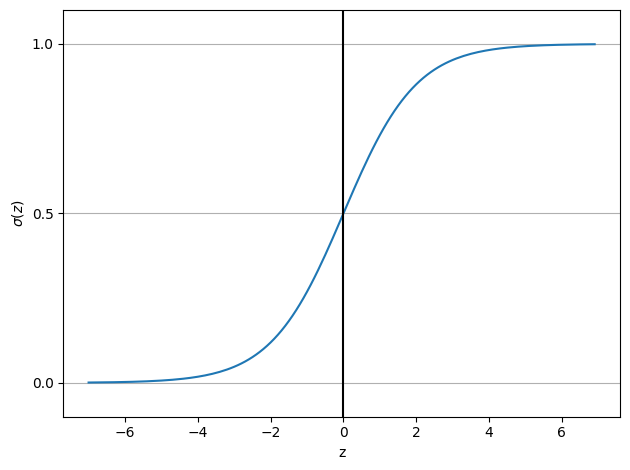

In [75]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

z = np.arange(-7, 7, 0.1)
sigma_z = sigmoid(z)

plt.plot(z, sigma_z)
plt.axvline(0.0, color='k')
plt.ylim(-0.1, 1.1)
plt.xlabel('z')
plt.ylabel(r'$\sigma (z)$')  # r''를 붙이면 → 백슬래시를 그대로 문자로 처리 → warning 사라짐

# y 축의 눈금과 격자선
plt.yticks([0.0, 0.5, 1.0])
ax = plt.gca()
ax.yaxis.grid(True)

plt.tight_layout()
#plt.savefig('figures/03_02.png', dpi=300)
plt.show()

#### 1-2 로지스틱 손실 함수의 가중치 학습

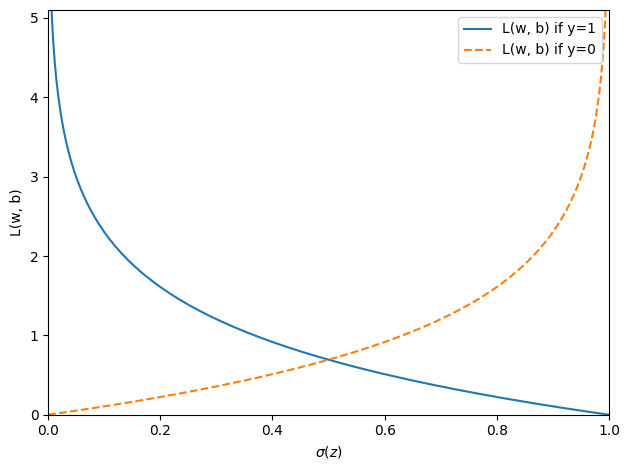

In [76]:
def loss_1(z):
    return -np.log(sigmoid(z))

def loss_0(z):
    return -np.log(1 - sigmoid(z))

z = np.arange(-10, 10, 0.1)
sigma_z = sigmoid(z)

c1 = [loss_1(x) for x in z]
plt.plot(sigma_z, c1, label=r'L(w, b) if y=1')

c0 = [loss_0(x) for x in z]
plt.plot(sigma_z, c0, linestyle='--', label=r'L(w, b) if y=0')

plt.ylim(0.0, 5.1)
plt.xlim([0, 1])
plt.xlabel(r'$\sigma(z)$')
plt.ylabel(r'L(w, b)')
plt.legend(loc='best')
plt.tight_layout()
#plt.savefig('figures/03_04.png', dpi=300)
plt.show()

#### 1-3 아달린 구현을 로지스틱 회귀 알고리즘으로 변경

In [77]:
class LogisticRegressionGD:
    # 경사 하강법을 사용한 로지스틱 회귀 분류기
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        # 훈련 데이터 학습
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.)
        self.losses_ = []

        for i in range(self.n_iter):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            errors = (y - output)
            self.w_ += self.eta * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * errors.mean()
            loss = (-y.dot(np.log(output)) - (1 - y).dot(np.log(1 - output))) / X.shape[0]
            self.losses_.append(loss)
        return self

    def net_input(self, X):
        # 최종 입력 계산
        return np.dot(X, self.w_) + self.b_

    z = np.arange(-10, 10, 0.1)
    def activation(self, z):
        # 로지스틱 시그모이드 활성화 계산
        return 1. / (1. + np.exp(-np.clip(z, -250, 250)))

    def predict(self, X):
        # 단위 계단 함수를 사용하여 클래스 레이블을 반환
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

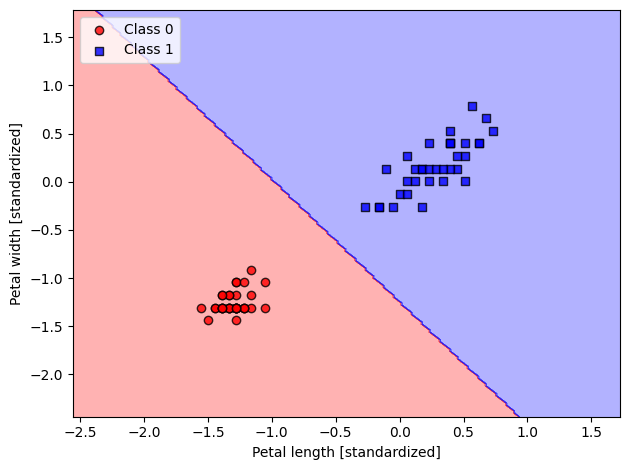

In [78]:
X_train_01_subset = X_train_std[(y_train == 0) | (y_train == 1)]
y_train_01_subset = y_train[(y_train == 0) | (y_train == 1)]

lrgd = LogisticRegressionGD(eta=0.3, n_iter=1000, random_state=1)
lrgd.fit(X_train_01_subset, y_train_01_subset)

plot_decision_regions(X=X_train_01_subset,
                      y=y_train_01_subset,
                      classifier=lrgd)

plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')

plt.tight_layout()
#plt.savefig('figures/03_05.png', dpi=300)
plt.show()

#### 1-4 PyTorch 버전 Adaline (SGD)

In [79]:
import numpy as np
import torch

class AdalineSGD_Torch:
    def __init__(self, eta=0.01, n_iter=10, shuffle=True, random_state=None, device=None):
        self.eta = eta
        self.n_iter = n_iter
        self.shuffle = shuffle
        self.random_state = random_state

        # 디바이스 설정 (GPU 자동 선택)
        self.device = device if device else (
            torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
        )

    def fit(self, X, y):
        # numpy → torch + device 이동
        X = torch.tensor(X, dtype=torch.float32).to(self.device)
        y = torch.tensor(y, dtype=torch.float32).view(-1, 1).to(self.device)

        # Adaline은 -1 / 1 권장
        y = torch.where(y == 0, -1, 1)

        if self.random_state:
            torch.manual_seed(self.random_state)

        n_samples, n_features = X.shape

        # leaf tensor로 초기화 (중요)
        self.w_ = torch.randn(n_features, 1, device=self.device)
        self.w_ *= 0.01
        self.w_.requires_grad_()

        self.b_ = torch.zeros(1, device=self.device, requires_grad=True)

        self.losses_ = []

        for _ in range(self.n_iter):

            if self.shuffle:
                indices = torch.randperm(n_samples, device=self.device)
                X = X[indices]
                y = y[indices]

            losses = []

            for xi, target in zip(X, y):
                xi = xi.view(1, -1)

                # 안전한 행렬 연산
                output = xi @ self.w_ + self.b_

                # MSE loss
                loss = (target - output) ** 2

                # backward
                loss.backward()

                # SGD 업데이트 (부호 중요!)
                with torch.no_grad():
                    self.w_ -= self.eta * self.w_.grad
                    self.b_ -= self.eta * self.b_.grad

                # gradient 초기화
                self.w_.grad.zero_()
                self.b_.grad.zero_()

                losses.append(loss.item())

            self.losses_.append(sum(losses) / len(losses))

        return self

    def net_input(self, X):
        X = torch.tensor(X, dtype=torch.float32).to(self.device)
        return X @ self.w_ + self.b_

    def predict(self, X):
        return torch.where(self.net_input(X) >= 0.0, 1, -1)

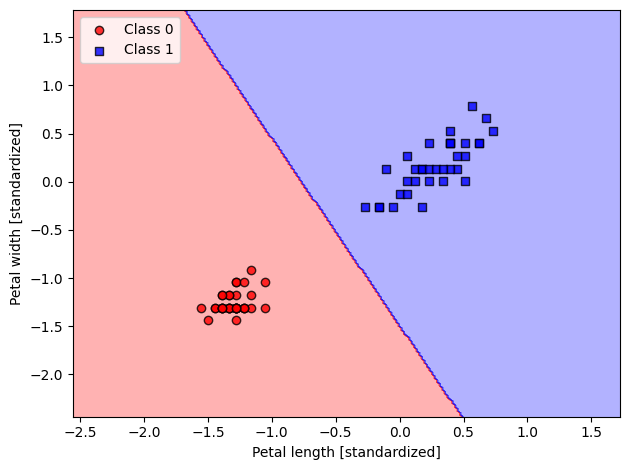

In [80]:
# 데이터 선택
X_train_01_subset = X_train_std[(y_train == 0) | (y_train == 1)]
y_train_01_subset = y_train[(y_train == 0) | (y_train == 1)]

# 모델 학습
lrgd = AdalineSGD_Torch(eta=0.01, n_iter=50, random_state=1)
lrgd.fit(X_train_01_subset, y_train_01_subset)

# GPU → CPU 변환 (시각화용 필수)
lrgd.w_ = lrgd.w_.detach().cpu()
lrgd.b_ = lrgd.b_.detach().cpu()

# predict도 numpy 대응으로 수정
def predict_numpy(X):
    X = torch.tensor(X, dtype=torch.float32)
    return torch.where(X @ lrgd.w_ + lrgd.b_ >= 0.0, 1, -1).numpy()

lrgd.predict = predict_numpy

# 시각화
plot_decision_regions(X=X_train_01_subset,
                      y=y_train_01_subset,
                      classifier=lrgd)

plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')

plt.tight_layout()
#plt.savefig('figures/03_05.png', dpi=300)
plt.show()

Epoch: 0,    Loss: 0.7094
Epoch: 20,    Loss: 0.3260
Epoch: 40,    Loss: 0.2377
Epoch: 60,    Loss: 0.2111
Epoch: 80,    Loss: 0.2025
Epoch: 100,    Loss: 0.1996
Epoch: 120,    Loss: 0.1989
Epoch: 140,    Loss: 0.1988
Epoch: 160,    Loss: 0.1987
Epoch: 180,    Loss: 0.1987


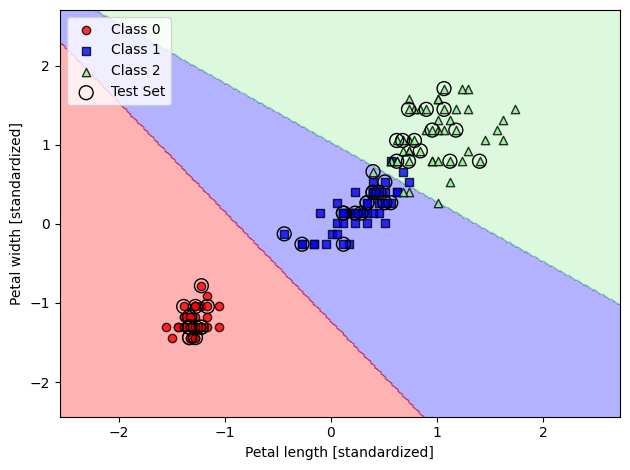

In [84]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. numpy → torch 변환
X_train_torch = torch.tensor(X_train_std, dtype=torch.float32)
y_train_torch = torch.tensor(y_train, dtype=torch.long)

X_combined_torch = torch.tensor(X_combined_std, dtype=torch.float32)
y_combined_torch = torch.tensor(y_combined, dtype=torch.long)

# 2. 모델 정의
class LogisticRegressionTorch(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.linear(x)

model = LogisticRegressionTorch(input_dim=2, num_classes=3)

# 3. 손실함수 & 옵티마이저
criterion = nn.CrossEntropyLoss()

# sklearn의 C=100 → weight_decay 작게
optimizer = optim.Adam(model.parameters(), lr=0.05, weight_decay=1/100.0)

# 4. 학습
for epoch in range(200):
    model.train()

    outputs = model(X_train_torch)
    loss = criterion(outputs, y_train_torch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch: {epoch},    Loss: {loss.item():.4f}")

# 5. sklearn 호환 Wrapper (핵심!)
class TorchClassifier:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            X_torch = torch.tensor(X, dtype=torch.float32)
            outputs = self.model(X_torch)
            _, predicted = torch.max(outputs, 1)
        return predicted.numpy()

torch_clf = TorchClassifier(model)

# 6. 결정경계 시각화
plot_decision_regions(X_combined_std, y_combined,
                      classifier=torch_clf,
                      test_idx=range(105, 150))

plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

#### 1-5 결정경계를 더 정밀하게 표현하기

In [85]:
def predict_proba_torch(model, X):
    model.eval()
    with torch.no_grad():
        X_torch = torch.tensor(X, dtype=torch.float32)
        outputs = model(X_torch)
        probs = torch.softmax(outputs, dim=1)
    return probs.numpy()

In [86]:
def plot_decision_regions_smooth(X, y, model, test_idx=None, resolution=0.01):
    from matplotlib.colors import ListedColormap

    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # 영역 범위
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # 해상도 증가 (핵심)
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))

    grid = np.array([xx1.ravel(), xx2.ravel()]).T

    # 확률 기반 예측
    probs = predict_proba_torch(model, grid)
    Z = np.argmax(probs, axis=1)
    Z = Z.reshape(xx1.shape)

    # 부드러운 contour
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)

    # 데이터 포인트
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=f'class {cl}',
                    edgecolor='black')

    # 테스트 데이터 강조
    if test_idx:
        X_test, y_test = X[test_idx, :], y[test_idx]
        plt.scatter(X_test[:, 0], X_test[:, 1],
                    c='none', edgecolor='black',
                    alpha=1.0, linewidth=1,
                    marker='o', s=100, label='test set')

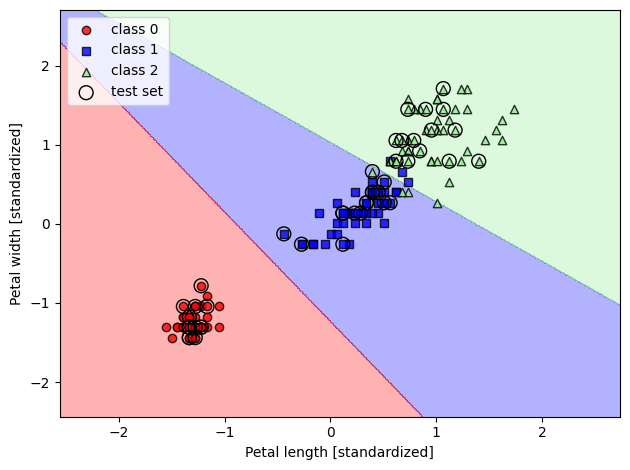

In [87]:
plot_decision_regions_smooth(X_combined_std, y_combined, model,
                             test_idx=range(105, 150),
                             resolution=0.01)  # ← 기본보다 훨씬 촘촘

plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

#### 1-6 위의 내용을 3D로 나타내기

In [88]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

def plot_3d_decision_surface(X, y, model, class_idx=0, resolution=0.02):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # 범위 설정
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))

    grid = np.array([xx1.ravel(), xx2.ravel()]).T

    # 확률 계산
    probs = predict_proba_torch(model, grid)
    Z = probs[:, class_idx].reshape(xx1.shape)

    # surface plot
    ax.plot_surface(xx1, xx2, Z, alpha=0.7)

    # 실제 데이터 (바닥에 표시)
    ax.scatter(X[:, 0], X[:, 1], 0, c=y, edgecolor='k')

    ax.set_xlabel('Petal length')
    ax.set_ylabel('Petal width')
    ax.set_zlabel(f'P(class={class_idx})')

    plt.title(f'3D Probability Surface (Class {class_idx})')
    plt.show()

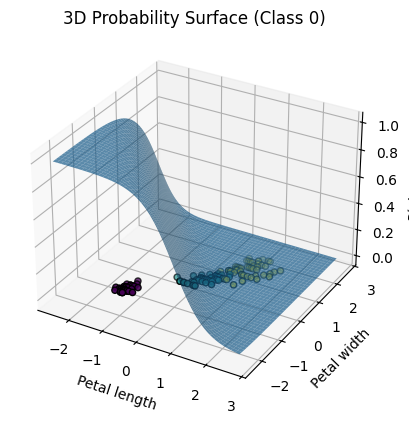

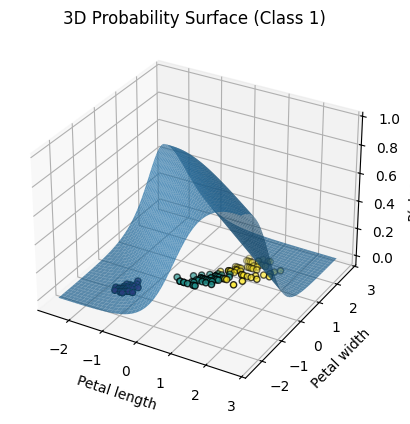

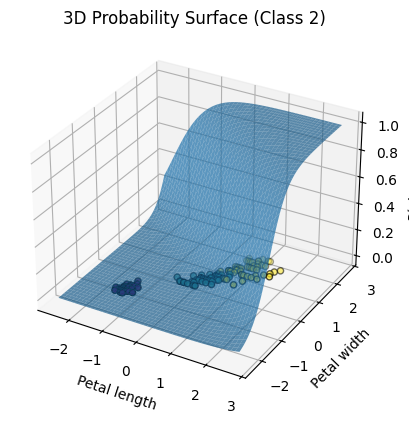

In [89]:
plot_3d_decision_surface(X_combined_std, y_combined, model, class_idx=0)
plot_3d_decision_surface(X_combined_std, y_combined, model, class_idx=1)
plot_3d_decision_surface(X_combined_std, y_combined, model, class_idx=2)

#### 1-7 3개의 클래스를 한 화면에 동시에 보기

In [90]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

def plot_3d_multi_surface(X, y, model, resolution=0.02):
    fig = plt.figure(figsize=(18, 5))

    # 범위 설정
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))

    grid = np.array([xx1.ravel(), xx2.ravel()]).T

    # 확률 계산 (한 번만!)
    probs = predict_proba_torch(model, grid)

    for class_idx in range(3):
        ax = fig.add_subplot(1, 3, class_idx + 1, projection='3d')

        Z = probs[:, class_idx].reshape(xx1.shape)

        # surface
        ax.plot_surface(xx1, xx2, Z, alpha=0.7)

        # 데이터 (바닥)
        ax.scatter(X[:, 0], X[:, 1], 0, c=y, edgecolor='k')

        ax.set_title(f'Class {class_idx}')
        ax.set_xlabel('Petal length')
        ax.set_ylabel('Petal width')
        ax.set_zlabel('Probability')

    plt.tight_layout()
    plt.show()

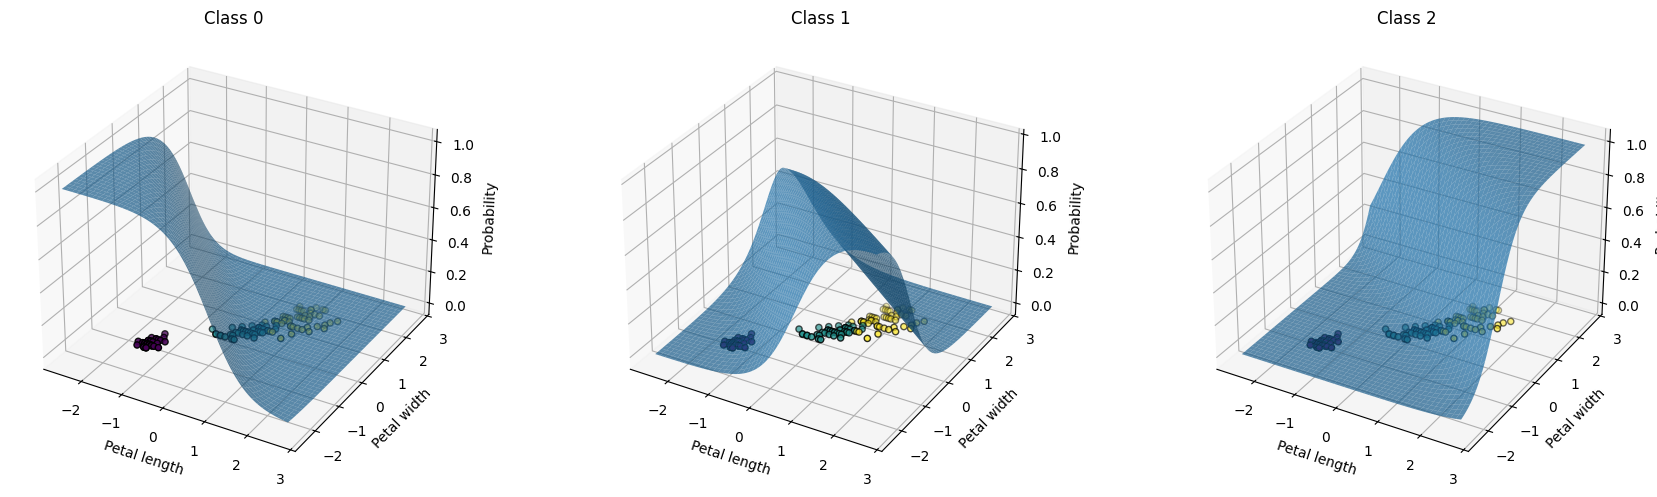

In [91]:
plot_3d_multi_surface(X_combined_std, y_combined, model, resolution=0.02)

#### 1-8 애니메이션으로 표현하기

In [92]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import animation
import numpy as np
import torch

In [93]:
# 애니메이션 함수
def animate_3d_surfaces(X, y, model, resolution=0.02, save_path='rotation.gif'):
    fig = plt.figure(figsize=(18, 5))

    # 범위 설정
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    grid = np.array([xx1.ravel(), xx2.ravel()]).T

    # 확률 계산
    model.eval()
    with torch.no_grad():
        X_torch = torch.tensor(grid, dtype=torch.float32)
        probs = torch.softmax(model(X_torch), dim=1).numpy()

    axes = []
    surfaces = []

    # 3개 subplot 생성
    for class_idx in range(3):
        ax = fig.add_subplot(1, 3, class_idx + 1, projection='3d')
        Z = probs[:, class_idx].reshape(xx1.shape)

        surf = ax.plot_surface(xx1, xx2, Z, alpha=0.7)
        ax.scatter(X[:, 0], X[:, 1], 0, c=y, edgecolor='k')

        ax.set_title(f'Class {class_idx}')
        ax.set_xlabel('Petal length')
        ax.set_ylabel('Petal width')
        ax.set_zlabel('Probability')

        axes.append(ax)
        surfaces.append(surf)

    # 🔥 회전 애니메이션
    def update(angle):
        for ax in axes:
            ax.view_init(elev=30, azim=angle)
        return axes

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=np.arange(0, 360, 2),  # 회전 속도
        interval=50
    )

    # 저장 (GIF)
    ani.save(save_path, writer='pillow')

    plt.show()

KeyboardInterrupt: 

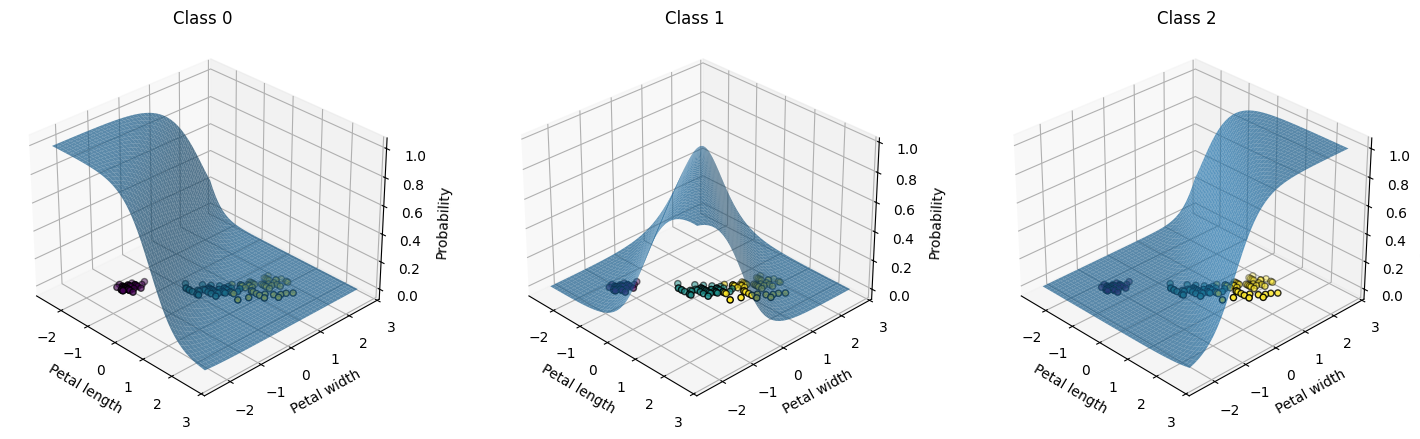

In [94]:
# # 실행
# animate_3d_surfaces(X_combined_std, y_combined, model,
#                     resolution=0.02,
#                     save_path='decision_surface.gif')